In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans

In [2]:
data = {
    'Model': ['Sedan_A', 'Sedan_B', 'SUV_A', 'SUV_B', 'Truck_A', 'Truck_B', 'Hatch_A', 'Hatch_B'],
    'EngineSize': [1.6, 1.8, 2.5, 3.0, 4.0, 4.2, 1.2, 1.4],
    'HorsePower': [110, 130, 200, 240, 320, 350, 90, 105],
    'TopSpeed': [180, 190, 210, 230, 250, 260, 160, 170],
    'FuelEfficiency': [18, 17, 12, 10, 8, 7, 22, 20]
}

vehicles = pd.DataFrame(data)
X = vehicles.iloc[:, 1:].values

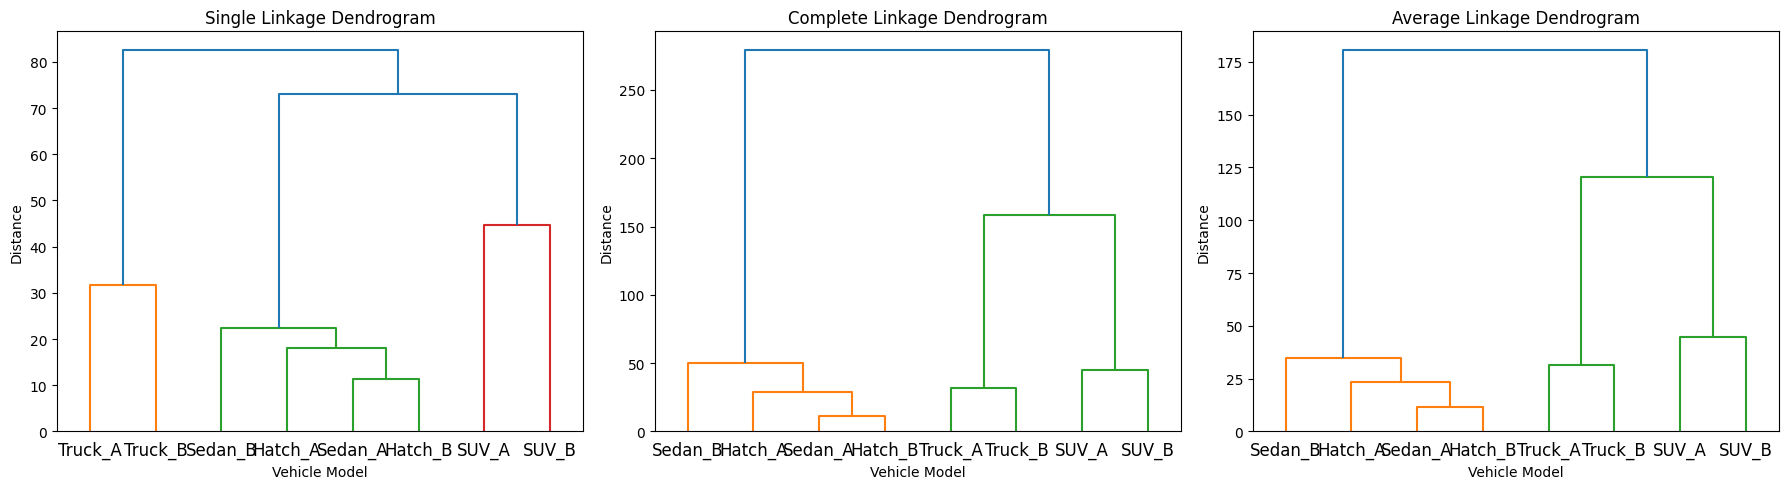

In [3]:
link_methods = ['single', 'complete', 'average']

plt.figure(figsize=(18, 5))
for i, method in enumerate(link_methods):
    plt.subplot(1, 3, i + 1)
    dendrogram(linkage(X, method=method), labels=vehicles['Model'].values)
    plt.title(f'{method.capitalize()} Linkage Dendrogram')
    plt.xlabel('Vehicle Model')
    plt.ylabel('Distance')
plt.tight_layout()
plt.show()

In [4]:
agg_model = AgglomerativeClustering(n_clusters=3, linkage='complete')
agg_labels = agg_model.fit_predict(X)
vehicles['Agglomerative_Group'] = agg_labels

print("\n📊 Agglomerative Clustering Groups:")
print(vehicles[['Model', 'Agglomerative_Group']])


📊 Agglomerative Clustering Groups:
     Model  Agglomerative_Group
0  Sedan_A                    0
1  Sedan_B                    0
2    SUV_A                    1
3    SUV_B                    1
4  Truck_A                    2
5  Truck_B                    2
6  Hatch_A                    0
7  Hatch_B                    0


In [5]:
def divisive_clustering(X, max_clusters=3):
    labels = np.zeros(len(X))
    clusters = [np.arange(len(X))]
    while len(clusters) < max_clusters:
        new_clusters = []
        for group in clusters:
            if len(group) > 1:
                kmeans = KMeans(n_clusters=2, random_state=42)
                kmeans.fit(X[group])
                cluster_labels = kmeans.labels_
                for j in np.unique(cluster_labels):
                    new_clusters.append(group[cluster_labels == j])
            else:
                new_clusters.append(group)
        clusters = new_clusters
        if len(clusters) >= max_clusters:
            break
    for i, group in enumerate(clusters):
        labels[group] = i
    return labels.astype(int)

div_labels = divisive_clustering(X, max_clusters=3)
vehicles['Divisive_Group'] = div_labels

print("\n📊 Divisive Clustering (Top-Down) Groups:")
print(vehicles[['Model', 'Divisive_Group']])


📊 Divisive Clustering (Top-Down) Groups:
     Model  Divisive_Group
0  Sedan_A               3
1  Sedan_B               2
2    SUV_A               0
3    SUV_B               0
4  Truck_A               1
5  Truck_B               1
6  Hatch_A               3
7  Hatch_B               3
